In [1]:
import numpy as np
import matplotlib.pyplot as plt
from plotsettings import *
import limpy.lline as ll

In [2]:
# Plot SFR with halomass in redshift range 0 to 8. 
# You can files using "read_sfr" function. or you can use inbuild "plot_sfr_mhalo" directly
# you may need to change the plotting parameters such as xlim, ylim, color etc....

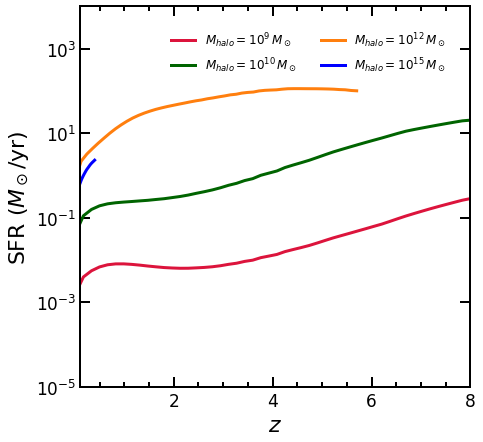

In [3]:
#plot
mhalo=[9e9,9e10, 1e12, 1e15]
z=np.linspace(0.1,8)
ll.plot_sfr_mhalo(mhalo,z)

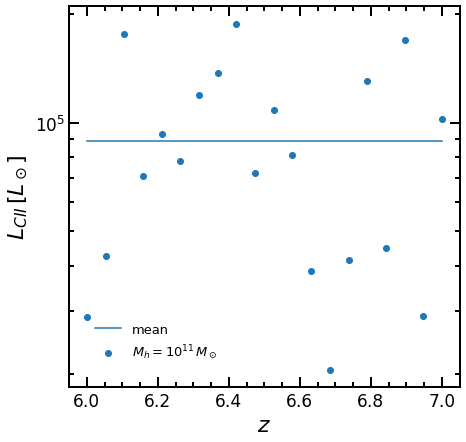

In [4]:
# plot luminosity of CII line at z=6 for the halo mass 1e11. 
# PLEASE NOTE that the result will change if you run the 
#same code again as we have used the scattered relation between SFR and CII luminosity
z=np.linspace(6,7,num=20)
line_name='OIII'
mh=[1e11]
lc2=np.zeros(len(z))
for i in range(len(z)):
    lc2[i]=ll.mhalo_to_lline(z[i],mh, line_name=line_name, use_scatter=True)

plt.scatter(z,lc2,label=r"$M_{h}=10^{11}\, M_\odot$")
plt.plot(z, np.mean(lc2)*np.ones(len(z)),label="mean")

plt.xlabel("$z$")
plt.ylabel(r"$L_{CII}\,[L_\odot]$")
plt.yscale("log")
plt.legend(loc=0,frameon=False)

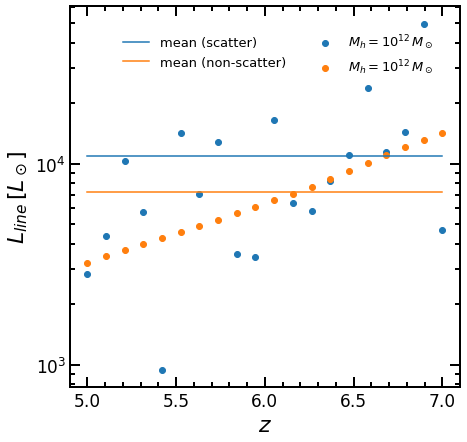

In [5]:
#Compare luminosity of CII line at z=6 for the halo mass 1e12 using LCII-SFR scatter and non-scatter relation. 
mh=[15]
z=np.linspace(5,7,num=20)
lc2_scatter=np.zeros(len(z))
lc2_nonscatter=np.zeros(len(z))
line_name='CII'
for i in range(len(z)):
    lc2_scatter[i]=ll.mhalo_to_lline(mh, z[i], line_name=line_name, use_scatter=True)
    lc2_nonscatter[i]=ll.mhalo_to_lline(mh, z[i], line_name=line_name, use_scatter=False)

plt.scatter(z,lc2_scatter,label=r"$M_{h}=10^{12}\, M_\odot$")
plt.plot(z, np.mean(lc2_scatter)*np.ones(len(z)),label="mean (scatter)")


plt.scatter(z,lc2_nonscatter,label=r"$M_{h}=10^{12}\, M_\odot$")
plt.plot(z, np.mean(lc2_nonscatter)*np.ones(len(z)),label="mean (non-scatter)")
plt.legend(loc=0)
plt.xlabel(r"$z$")
plt.yscale("log")
plt.ylabel(r"$L_{line}\,[L_\odot]$")
plt.legend(loc=1,ncol=2,frameon=False)
#plt.ylim(6.0,8)

Text(0, 0.5, '$\\log(L_{CII})\\,\\,[L_\\odot]$')

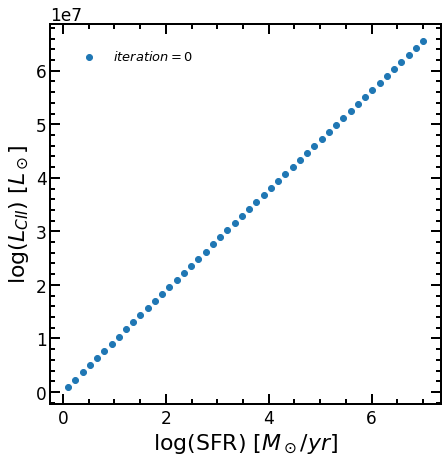

In [6]:
# Make same plot for 5 times at z=6, for different star formation rate to check the Gaussian scatter in L_{CII}
z=7 #redshift
sfr=np.linspace(0.1,7,num=50) #SFR rate
num_of_iteration=1
line_name='CII'
for i in range(num_of_iteration):
    lc2=ll.sfr_to_lcp_nonscatter(z, sfr)
    
    #scatter lc2 points
    plt.scatter(sfr,lc2,label=r"$iteration=%d$" %(i))
    plt.legend(loc=0,frameon=False)
    
plt.xlabel(r"$\log(\mathrm{SFR})\,\,[M_\odot/yr]$")
plt.ylabel(r"$\log(L_{CII})\,\,[L_\odot]$")
#plt.ylim(4.0,9)

Text(0, 0.5, '$\\log(L_{CII})\\,\\,[L_\\odot]$')

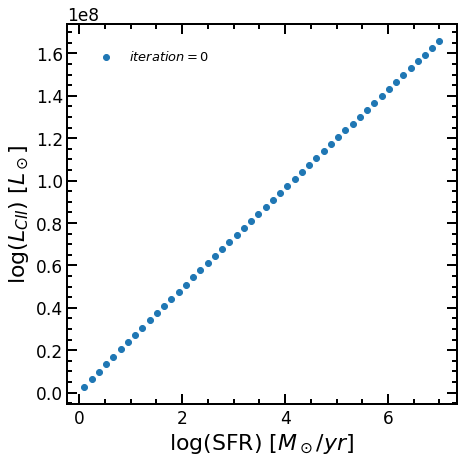

In [7]:
# Make same plot for 5 times at z=6, for different star formation rate to check the Gaussian scatter in L_{CII}
z=7 #redshift
sfr=np.linspace(0.1,7,num=50) #SFR rate
num_of_iteration=1
line_name='OIII'
for i in range(num_of_iteration):
    lc2=ll.sfr_to_lot_nonscatter(z, sfr)
    
    #scatter lc2 points
    plt.scatter(sfr,lc2,label=r"$iteration=%d$" %(i))
    plt.legend(loc=0,frameon=False)
    
plt.xlabel(r"$\log(\mathrm{SFR})\,\,[M_\odot/yr]$")
plt.ylabel(r"$\log(L_{CII})\,\,[L_\odot]$")
#plt.ylim(4.0,9)



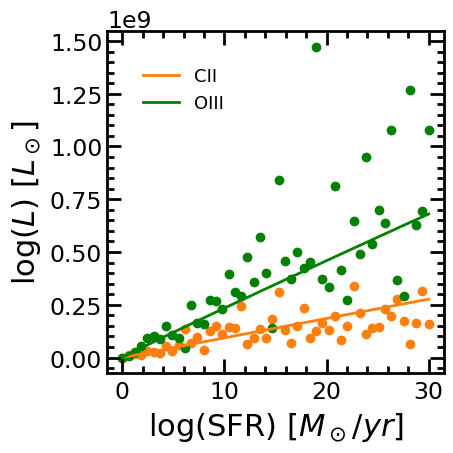

In [8]:
# Make same plot for 5 times at z=6, for different star formation rate to check the Gaussian scatter in L_{CII}
z1=7 #redshift
z2=6 #redshift
sfr=np.linspace(0.01,30,num=50) #SFR rate

lc2_z1=ll.sfr_to_lcp_nonscatter(z1, sfr)
lo3_z1=ll.sfr_to_lot_nonscatter(z2, sfr)

lc2_z1_sca=ll.sfr_to_lcp_scatter(z1, sfr)
lo3_z1_sca=ll.sfr_to_lot_scatter(z2, sfr)


plt.figure(figsize=(5,5), dpi=100)
plt.plot(sfr, lc2_z1, lw=2, color='C1', label="CII")
plt.plot(sfr, lo3_z1, lw=2, color='green', label="OIII")

plt.scatter(sfr, lc2_z1_sca, color='C1')
plt.scatter(sfr, lo3_z1_sca, color='green')

plt.xlabel(r"$\log(\mathrm{SFR})\,\,[M_\odot/yr]$")
plt.ylabel(r"$\log(L)\,\,[L_\odot]$")
#plt.ylim(4.0,9)
plt.legend(loc=0, frameon=False)

plt.tight_layout()
plt.savefig("line_comparison.png")

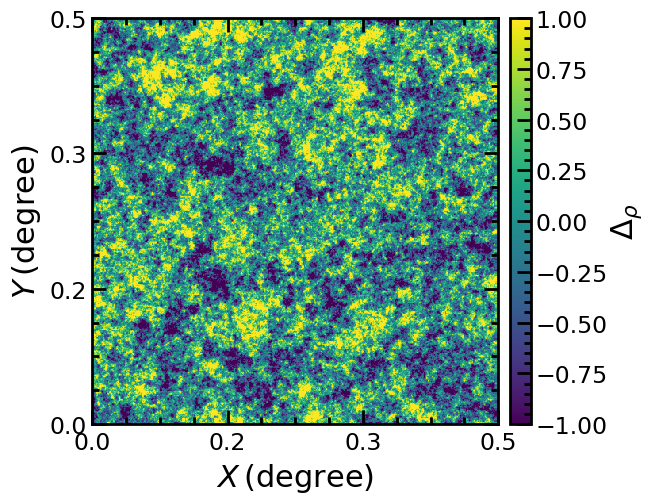

In [9]:
"""
plot_slice module can make slice plots for density.

This function takes few inputs as described below. 

Set "True" for any of these arguments at a time: density_plot,
           halo_overplot, and plot_lines.
"""

boxsize=80  # Size of the box in comoving Mpc (cMpc)
ngrid= 512  # number of grids along the box axis
nproj=10    # no of cells to project
halo_redshift=7.6 # redshift of halos, (Note: at this point it is not used in the function)


#It can read halos and density only from the redshift information but now, lets just do it for one redshift 
# by manually providng the files

#location of density file
path_21cm="/Users/anirbanroy/Documents/21cmFAST/"

dens_file=path_21cm+'/Boxes/updated_smoothed_deltax_z00%1.2f_%d_%dMpc' %(halo_redshift, ngrid,boxsize)

#location of halo catalogue file

halocat_file=path_21cm+'Output_files/Halo_lists/halos_z%1.2f_%d_%dMpc' %(halo_redshift, ngrid,boxsize)

'''
#plot only the density slice
ll.plot_slice(boxsize, ngrid, nproj, dens_file, halocat_file,halo_redshift,halo_cutoff_mass_log=8, density_plot=True,
           halo_overplot=False ,plot_lines=False,  tick_label='degree')
'''

# overplot halos on the density distribution
ll.plot_slice(boxsize, ngrid, nproj, dens_file, halocat_file,halo_redshift,halo_cutoff_mass=1e11, density_plot=True,
           halo_overplot=False ,plot_lines=False, unit='degree')

plt.savefig("dens_halos_L80N512_z4.4_log_mmin8.png")

Minimum halo mass: 336666900.0
Maximum halo mass: 321717300000.0


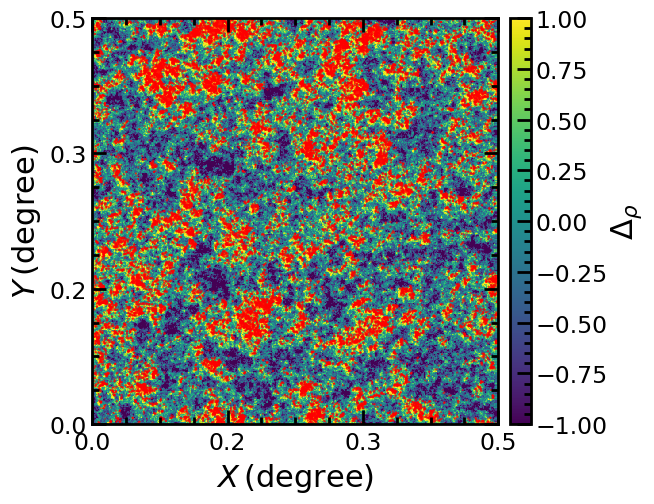

In [10]:
# overplot halos on the density distribution
ll.plot_slice(boxsize, ngrid, nproj, dens_file, halocat_file,halo_redshift,halo_cutoff_mass=1e8, density_plot=False,
           halo_overplot=True ,plot_lines=False, unit='degree')

Minimum halo mass: 336666900.0
Maximum halo mass: 321717300000.0


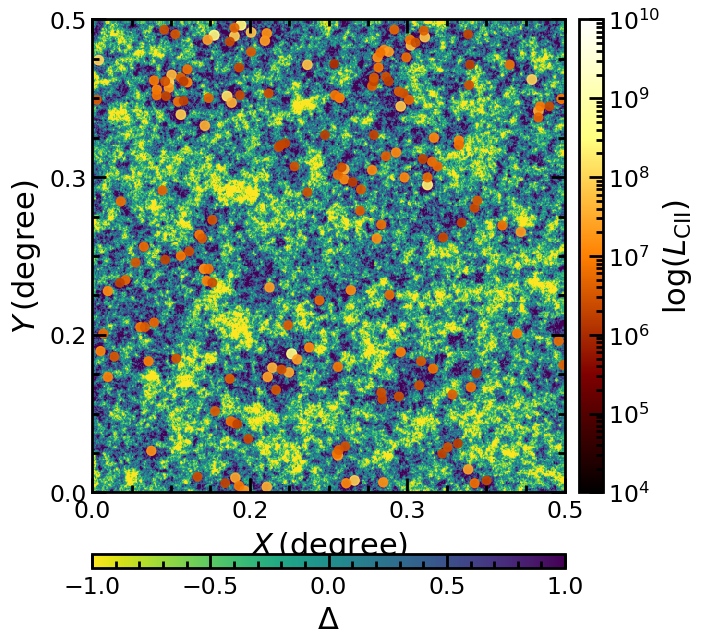

In [11]:
# Overplot CII line luminosities on the density distribution using SFR-CII scatter relation
ll.plot_slice(boxsize, ngrid, nproj, dens_file, halocat_file,halo_redshift,halo_cutoff_mass=1e10, use_scatter=True, density_plot=False,
           halo_overplot=False ,plot_lines=True, unit='degree')

Minimum halo mass: 336666900.0
Maximum halo mass: 321717300000.0


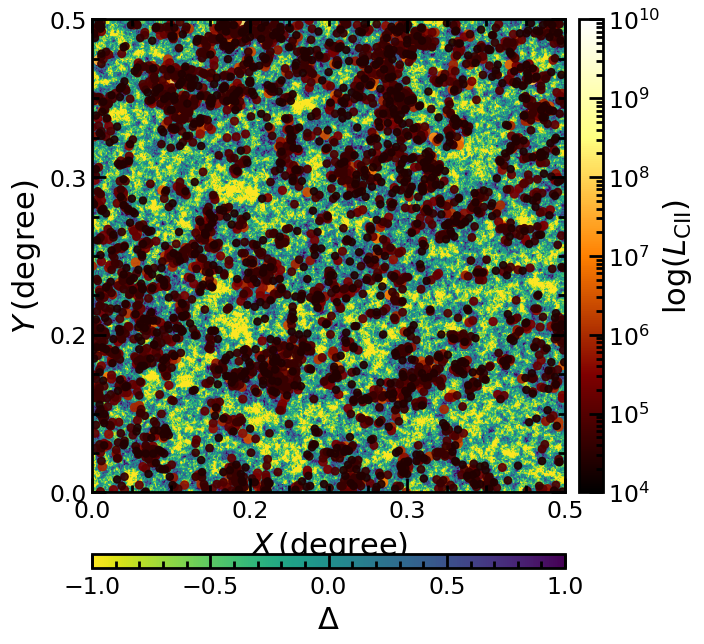

In [12]:
# Overplot CII line luminosities on the density distribution using SFR-CII NON-scatter relation
ll.plot_slice(boxsize, ngrid, nproj, dens_file, halocat_file,halo_redshift,halo_cutoff_mass=1e9, use_scatter=False, density_plot=False,
           halo_overplot=False ,plot_lines=True, unit='degree')